# Experiment 2: Standalone BERT vs BERT + GAT Hybrid

Compares three architectures on the same datasets as Experiment 1:

| Architecture | Node features | What trains | lr |
|---|---|---|---|
| **Standalone BERT** | — | Full BERT + linear head | 2e-5 |
| **BERT + GAT (frozen)** | Frozen BERT token embeddings (768-d) | GAT layers + classifier only | 1e-3 |
| **BERT + GAT (end-to-end)** | BERT embeddings computed on-the-fly | BERT + GAT + classifier | 2e-5 / 1e-3 |

The frozen-BERT variant (2a) isolates the contribution of graph structure from that of fine-tuning.  
The end-to-end variant (2b) tests whether graph structure helps when BERT adapts simultaneously.


In [10]:
import random, copy, os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from datasets import load_dataset
from scipy.stats import ttest_rel
import spacy

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader as TorchDataLoader


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

nlp = spacy.load('en_core_web_sm', disable=['ner'])
nlp.max_length = 2_000_000

Device: cuda


In [11]:
def load_scientific_text_classification(n_per_class=200, seed=42):
    ds = load_dataset('knowledgator/Scientific-text-classification')
    frames = [pd.DataFrame(ds[split]) for split in ds.keys()]
    df = pd.concat(frames, ignore_index=True)
    df['text'] = df['text'].astype(str)
    df = df[df['text'].str.strip().str.len() > 100].copy()
    top_labels = df['label'].value_counts().head(8).index.tolist()
    df = df[df['label'].isin(top_labels)].copy()
    old_to_new = {old: new for new, old in enumerate(sorted(top_labels))}
    new_to_old = {v: k for k, v in old_to_new.items()}
    df['original_label'] = df['label']
    df['label'] = df['label'].map(old_to_new)
    dfs = []
    for lbl in df['label'].unique():
        subset = df[df['label'] == lbl]
        dfs.append(subset.sample(min(len(subset), n_per_class), random_state=seed))
    return pd.concat(dfs, ignore_index=True), old_to_new, new_to_old


def load_imdb_kaggle(n_per_class=1000, seed=42):
    path = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')
    df = pd.read_csv(os.path.join(path, 'IMDB Dataset.csv'))
    df['text'] = df['review'].astype(str)
    df = df[df['text'].str.strip().str.len() > 100].copy()
    old_to_new = {'negative': 0, 'positive': 1}
    new_to_old = {0: 'negative', 1: 'positive'}
    df['original_label'] = df['sentiment']
    df['label'] = df['sentiment'].map(old_to_new)
    dfs = []
    for lbl in df['label'].unique():
        subset = df[df['label'] == lbl]
        dfs.append(subset.sample(min(len(subset), n_per_class), random_state=seed))
    return pd.concat(dfs, ignore_index=True), old_to_new, new_to_old


df_scientific, sci_old_to_new, sci_new_to_old   = load_scientific_text_classification()
df_imdb,       imdb_old_to_new, imdb_new_to_old = load_imdb_kaggle()
print('Scientific:', df_scientific.shape, '  IMDb:', df_imdb.shape)

Scientific: (1600, 3)   IMDb: (2000, 5)


In [12]:
def make_splits(df, seed=42, train_size=0.70, val_size=0.15, test_size=0.15):
    texts  = df['text'].tolist()
    labels = df['label'].astype(int).tolist()
    tr_t, tmp_t, tr_y, tmp_y = train_test_split(
        texts, labels, train_size=train_size, stratify=labels, random_state=seed)
    rel_val = val_size / (val_size + test_size)
    val_t, te_t, val_y, te_y = train_test_split(
        tmp_t, tmp_y, train_size=rel_val, stratify=tmp_y, random_state=seed)
    return tr_t, val_t, te_t, tr_y, val_y, te_y


def process_spacy_doc(doc, max_tokens=256):
    token_info = []
    for tok in doc:
        if tok.is_space or tok.is_punct:
            continue
        token_info.append({
            'text': tok.text.lower(), 'i': tok.i, 'head_i': tok.head.i,
            'dep': tok.dep_, 'pos': tok.pos_, 'is_alpha': tok.is_alpha
        })
        if len(token_info) >= max_tokens:
            break
    return token_info


def build_cooccurrence_edges(token_info, window_size=3):
    n = len(token_info)
    if n == 0:
        return torch.tensor([[0], [0]], dtype=torch.long)
    edges = set()
    for i in range(n):
        edges.add((i, i))
        for j in range(max(0, i - window_size), min(n, i + window_size + 1)):
            if i != j:
                edges.add((i, j)); edges.add((j, i))
    return torch.tensor(list(edges), dtype=torch.long).t().contiguous()


def build_dependency_edges(token_info):
    n = len(token_info)
    if n == 0:
        return torch.tensor([[0], [0]], dtype=torch.long)
    edges = set()
    orig_to_node = {tok['i']: ni for ni, tok in enumerate(token_info)}
    for ni, tok in enumerate(token_info):
        edges.add((ni, ni))
        hi = orig_to_node.get(tok['head_i'])
        if hi is not None and hi != ni:
            edges.add((ni, hi)); edges.add((hi, ni))
    return torch.tensor(list(edges), dtype=torch.long).t().contiguous()


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(batch), batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_full(model, loader):
    model.eval()
    preds, labs = [], []
    for batch in loader:
        batch = batch.to(device)
        preds.extend(model(batch).argmax(dim=1).cpu().numpy())
        labs.extend(batch.y.view(-1).cpu().numpy())
    return accuracy_score(labs, preds), f1_score(labs, preds, average='macro'), preds, labs

In [13]:
BERT_MODEL_NAME = 'bert-base-uncased'
bert_tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_encoder    = AutoModel.from_pretrained(BERT_MODEL_NAME).to(device)
bert_encoder.eval()
for p in bert_encoder.parameters():
    p.requires_grad = False
print('BERT encoder loaded (frozen). Hidden size:', bert_encoder.config.hidden_size)


@torch.no_grad()
def compute_bert_node_features(token_info_list, tokenizer, model, device, batch_size=32):
    all_embs = []
    for start in tqdm(range(0, len(token_info_list), batch_size), desc='BERT encode'):
        for token_info in token_info_list[start:start + batch_size]:
            words = [tok['text'] for tok in token_info]
            if not words:
                all_embs.append(torch.zeros(1, 768))
                continue
            enc = tokenizer(
                words, is_split_into_words=True, return_tensors='pt',
                padding=False, truncation=True, max_length=512
            ).to(device)
            hidden   = model(**enc).last_hidden_state[0]
            word_ids = enc.word_ids(batch_index=0)
            n = len(words)
            emb    = torch.zeros(n, 768, device=device)
            counts = torch.zeros(n, device=device)
            for j, wid in enumerate(word_ids):
                if wid is not None:
                    emb[wid] += hidden[j]
                    counts[wid] += 1
            counts = counts.clamp(min=1)
            all_embs.append((emb / counts.unsqueeze(1)).cpu())
    return all_embs

BERT encoder loaded (frozen). Hidden size: 768


In [14]:
class BERTGraphGAT(nn.Module):
    def __init__(self, num_classes, bert_dim=768, hidden_dim=64, heads=4, dropout=0.3):
        super().__init__()
        self.gat1 = GATConv(bert_dim, hidden_dim, heads=heads,
                            concat=True, dropout=dropout, add_self_loops=False)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1,
                            concat=False, dropout=dropout, add_self_loops=False)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, batch):
        x = batch.x.float()
        x = F.elu(self.gat1(x, batch.edge_index))
        x = self.dropout(x)
        x = F.elu(self.gat2(x, batch.edge_index))
        return self.classifier(self.dropout(global_mean_pool(x, batch.batch)))


class StandaloneBERT(nn.Module):
    def __init__(self, num_classes, bert_model_name=BERT_MODEL_NAME, dropout=0.3):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(bert_model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        cls = self.bert(input_ids=input_ids,
                        attention_mask=attention_mask).last_hidden_state[:, 0]
        return self.classifier(self.dropout(cls))


class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.enc    = tokenizer(list(texts), padding=True, truncation=True,
                                max_length=max_length, return_tensors='pt')
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.enc['input_ids'][idx],
            'attention_mask': self.enc['attention_mask'][idx],
            'label':          self.labels[idx],
        }


def run_experiment_bert_gat(train_loader, val_loader, test_loader, num_classes,
                             seeds=[13, 21, 42, 87, 100], patience=5, max_epochs=30):
    all_accs, all_f1s = [], []
    best_preds, best_labels = None, None
    for seed in seeds:
        set_seed(seed)
        model     = BERTGraphGAT(num_classes).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        best_f1, wait, best_state = -1, 0, None
        for _ in range(1, max_epochs + 1):
            train_one_epoch(model, train_loader, optimizer)
            _, val_f1, _, _ = evaluate_full(model, val_loader)
            if val_f1 > best_f1:
                best_f1, wait = val_f1, 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                wait += 1
            if wait >= patience:
                break
        model.load_state_dict(best_state)
        acc, f1, preds, labs = evaluate_full(model, test_loader)
        all_accs.append(acc); all_f1s.append(f1)
        best_preds, best_labels = preds, labs
    return dict(acc_mean=np.mean(all_accs)*100, acc_std=np.std(all_accs, ddof=1)*100,
                f1_mean=np.mean(all_f1s)*100,   f1_std=np.std(all_f1s,  ddof=1)*100,
                all_accs=all_accs, all_f1s=all_f1s, preds=best_preds, labels=best_labels)


def run_experiment_bert_standalone(train_texts, val_texts, test_texts,
                                    train_y, val_y, test_y, num_classes,
                                    seeds=[13, 21, 42, 87, 100], patience=3, max_epochs=5):
    all_accs, all_f1s = [], []
    best_preds, best_labels = None, None
    train_ds = TextDataset(train_texts, train_y, bert_tokenizer)
    val_ds   = TextDataset(val_texts,   val_y,   bert_tokenizer)
    test_ds  = TextDataset(test_texts,  test_y,  bert_tokenizer)
    tr_ldr  = TorchDataLoader(train_ds, batch_size=16, shuffle=True)
    val_ldr = TorchDataLoader(val_ds,   batch_size=16, shuffle=False)
    te_ldr  = TorchDataLoader(test_ds,  batch_size=16, shuffle=False)
    for seed in seeds:
        set_seed(seed)
        model     = StandaloneBERT(num_classes).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
        best_f1, wait, best_state = -1, 0, None
        for _ in range(1, max_epochs + 1):
            model.train()
            for batch in tr_ldr:
                optimizer.zero_grad()
                logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
                F.cross_entropy(logits, batch['label'].to(device)).backward()
                optimizer.step()
            model.eval()
            preds, labs = [], []
            with torch.no_grad():
                for batch in val_ldr:
                    logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
                    preds.extend(logits.argmax(1).cpu().numpy())
                    labs.extend(batch['label'].numpy())
            val_f1 = f1_score(labs, preds, average='macro')
            if val_f1 > best_f1:
                best_f1, wait = val_f1, 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                wait += 1
            if wait >= patience:
                break
        model.load_state_dict(best_state)
        model.eval()
        preds, labs = [], []
        with torch.no_grad():
            for batch in te_ldr:
                logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
                preds.extend(logits.argmax(1).cpu().numpy())
                labs.extend(batch['label'].numpy())
        all_accs.append(accuracy_score(labs, preds))
        all_f1s.append(f1_score(labs, preds, average='macro'))
        best_preds, best_labels = preds, labs
    return dict(acc_mean=np.mean(all_accs)*100, acc_std=np.std(all_accs, ddof=1)*100,
                f1_mean=np.mean(all_f1s)*100,   f1_std=np.std(all_f1s,  ddof=1)*100,
                all_accs=all_accs, all_f1s=all_f1s, preds=best_preds, labels=best_labels)

In [15]:
def make_bert_pyg_graph(bert_emb, token_info, label, graph_type='dep', window_size=3):
    if bert_emb.size(0) == 0:
        bert_emb   = torch.zeros(1, 768)
        edge_index = torch.tensor([[0], [0]], dtype=torch.long)
    else:
        edge_index = (build_cooccurrence_edges(token_info, window_size)
                      if graph_type == 'cooc' else build_dependency_edges(token_info))
    g = Data(x=bert_emb.float(), edge_index=edge_index,
             y=torch.tensor([label], dtype=torch.long))
    g.num_nodes = bert_emb.size(0)
    return g


def make_bert_graph_dataset(bert_embeddings, token_info_list, labels, graph_type='dep'):
    return [make_bert_pyg_graph(e, t, l, graph_type)
            for e, t, l in zip(bert_embeddings, token_info_list, labels)]


def run_experiment2_pipeline(df, dataset_name, label_names_dict, graph_type='dep'):
    print('\n=== Experiment 2:', dataset_name, '===')
    tr_texts, val_texts, te_texts, tr_y, val_y, te_y = make_splits(df, seed=42)
    num_classes = df['label'].nunique()

    def tok_texts(texts):
        return [process_spacy_doc(d) for d in tqdm(nlp.pipe(texts, batch_size=64), total=len(texts))]

    tr_tok  = tok_texts(tr_texts)
    val_tok = tok_texts(val_texts)
    te_tok  = tok_texts(te_texts)

    print('Computing frozen BERT node features...')
    tr_bert  = compute_bert_node_features(tr_tok,  bert_tokenizer, bert_encoder, device)
    val_bert = compute_bert_node_features(val_tok, bert_tokenizer, bert_encoder, device)
    te_bert  = compute_bert_node_features(te_tok,  bert_tokenizer, bert_encoder, device)

    tr_graphs  = make_bert_graph_dataset(tr_bert,  tr_tok,  tr_y,  graph_type)
    val_graphs = make_bert_graph_dataset(val_bert, val_tok, val_y, graph_type)
    te_graphs  = make_bert_graph_dataset(te_bert,  te_tok,  te_y,  graph_type)

    gat_tr  = DataLoader(tr_graphs,  batch_size=32, shuffle=True)
    gat_val = DataLoader(val_graphs, batch_size=32, shuffle=False)
    gat_te  = DataLoader(te_graphs,  batch_size=32, shuffle=False)

    print('Training BERT + GAT...')
    res_gat = run_experiment_bert_gat(gat_tr, gat_val, gat_te, num_classes)

    print('Fine-tuning standalone BERT...')
    res_bert = run_experiment_bert_standalone(
        tr_texts, val_texts, te_texts, tr_y, val_y, te_y, num_classes)

    _, p_f1 = ttest_rel(res_gat['all_f1s'], res_bert['all_f1s'])

    gam, gas = res_gat['acc_mean'],  res_gat['acc_std']
    gfm, gfs = res_gat['f1_mean'],   res_gat['f1_std']
    bam, bas = res_bert['acc_mean'],  res_bert['acc_std']
    bfm, bfs = res_bert['f1_mean'],   res_bert['f1_std']

    print('[{}] Results (5 seeds):'.format(dataset_name))
    print('  BERT + GAT      -> Acc: {:.2f}+/-{:.2f}%  F1: {:.2f}+/-{:.2f}%'.format(gam, gas, gfm, gfs))
    print('  Standalone BERT -> Acc: {:.2f}+/-{:.2f}%  F1: {:.2f}+/-{:.2f}%'.format(bam, bas, bfm, bfs))
    print('  p-value (F1, paired t-test): {:.4f}'.format(p_f1))

    target_names = [label_names_dict.get(i, str(i)) for i in range(num_classes)]
    print('\nBERT+GAT classification report (last seed):')
    print(classification_report(res_gat['labels'],  res_gat['preds'],  target_names=target_names))
    print('\nStandalone BERT classification report (last seed):')
    print(classification_report(res_bert['labels'], res_bert['preds'], target_names=target_names))

    return res_gat, res_bert

In [16]:
res2_sci_gat,  res2_sci_bert  = run_experiment2_pipeline(
    df_scientific, 'Scientific Text',    sci_new_to_old,  graph_type='dep')
res2_imdb_gat, res2_imdb_bert = run_experiment2_pipeline(
    df_imdb,       'IMDb Movie Reviews', imdb_new_to_old, graph_type='dep')


=== Experiment 2: Scientific Text ===


  0%|          | 0/1120 [00:00<?, ?it/s]

  0%|          | 0/240 [00:00<?, ?it/s]

  0%|          | 0/240 [00:00<?, ?it/s]

Computing frozen BERT node features...


...

Computing frozen BERT node features...


BERT encode:   0%|          | 0/44 [00:00<?, ?it/s]

BERT encode:   0%|          | 0/10 [00:00<?, ?it/s]

BERT encode:   0%|          | 0/10 [00:00<?, ?it/s]

Training BERT + GAT...
Fine-tuning standalone BERT...
[IMDb Movie Reviews] Results (5 seeds):
  BERT + GAT      -> Acc: 86.47+/-0.69%  F1: 86.46+/-0.69%
  Standalone BERT -> Acc: 89.60+/-0.72%  F1: 89.59+/-0.72%
  p-value (F1, paired t-test): 0.0001

BERT+GAT classification report (last seed):
              precision    recall  f1-score   support

    negative       0.87      0.83      0.85       150
    positive       0.84      0.88      0.86       150

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300


Standalone BERT classification report (last seed):
              precision    recall  f1-score   support

    negative       0.91      0.85      0.88       150
    positive       0.86      0.92      0.89       150

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300


In [18]:
import json
import matplotlib.pyplot as plt
os.makedirs('results', exist_ok=True)

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if hasattr(obj, 'item'):   return obj.item()
        if hasattr(obj, 'tolist'): return obj.tolist()
        return super().default(obj)

def save_results(path, data):
    with open(path, 'w') as f:
        json.dump(data, f, indent=2, cls=NumpyEncoder)
    print('Saved:', path)

save_results('results/exp2_frozen_results.json', {
    'scientific': {'bert_gat_frozen': res2_sci_gat,  'standalone_bert': res2_sci_bert},
    'imdb':       {'bert_gat_frozen': res2_imdb_gat, 'standalone_bert': res2_imdb_bert},
})


Saved: results/exp2_frozen_results.json


## Analysis — Why Standalone BERT Won

In the frozen variant above, BERT+GAT consistently underperforms standalone BERT (e.g. IMDb: 86.2% vs 89.5% F1). The reason is architectural, not fundamental:

| Factor | BERT+GAT (frozen) | Standalone BERT |
|---|---|---|
| Trained parameters | ~1M (GAT only) | ~110M (full BERT) |
| BERT representations | static, pre-trained | adapted to the task |
| Graph structure used | yes | no |

Freezing BERT isolates the graph's contribution — a valid research choice — but it structurally disadvantages the hybrid against a fully fine-tuned model.

## Experiment 2b — BERT + GAT End-to-End

BERT is now trained **jointly** with the GAT using two learning rates:
- BERT layers: `lr = 2e-5` (small, to preserve pre-trained knowledge)
- GAT + classifier: `lr = 1e-3` (larger, for fast adaptation of graph layers)

The research question shifts to: *"Does explicit dependency-graph structure help when BERT can adapt simultaneously?"*



In [19]:
def make_e2e_data(token_info, tokenizer, label, graph_type='dep', window_size=3):
    """Single document → dict with BERT inputs + graph structure for end-to-end training."""
    words = [tok['text'] for tok in token_info]
    n = len(words)
    if n == 0:
        return {
            'input_ids':      torch.tensor([101, 102], dtype=torch.long),
            'attention_mask': torch.tensor([1, 1],     dtype=torch.long),
            'word_ids':       torch.tensor([-1, -1],   dtype=torch.long),
            'n_nodes':        1,
            'edge_index':     torch.tensor([[0], [0]], dtype=torch.long),
            'y':              torch.tensor([label],    dtype=torch.long),
        }
    enc = tokenizer(words, is_split_into_words=True, return_tensors='pt',
                    padding=False, truncation=True, max_length=512)
    wids = torch.tensor(
        [w if w is not None else -1 for w in enc.word_ids(0)], dtype=torch.long)
    edge_index = (build_cooccurrence_edges(token_info, window_size)
                  if graph_type == 'cooc' else build_dependency_edges(token_info))
    return {
        'input_ids':      enc['input_ids'][0],
        'attention_mask': enc['attention_mask'][0],
        'word_ids':       wids,
        'n_nodes':        n,
        'edge_index':     edge_index,
        'y':              torch.tensor([label], dtype=torch.long),
    }


def e2e_collate_fn(batch):
    """Pad BERT inputs, shift edge indices by cumulative node offsets, build batch vector."""
    max_seq = max(b['input_ids'].size(0) for b in batch)
    input_ids, attn_masks, word_ids_padded, edges, ys, batch_vec = [], [], [], [], [], []
    node_offset = 0
    for i, b in enumerate(batch):
        pad = max_seq - b['input_ids'].size(0)
        input_ids.append(F.pad(b['input_ids'],      (0, pad), value=0))
        attn_masks.append(F.pad(b['attention_mask'], (0, pad), value=0))
        word_ids_padded.append(F.pad(b['word_ids'], (0, pad), value=-1))
        edges.append(b['edge_index'] + node_offset)
        ys.append(b['y'])
        batch_vec.extend([i] * b['n_nodes'])
        node_offset += b['n_nodes']
    return {
        'input_ids':      torch.stack(input_ids),
        'attention_mask': torch.stack(attn_masks),
        'word_ids':       torch.stack(word_ids_padded),
        'edge_index':     torch.cat(edges, dim=1),
        'y':              torch.cat(ys),
        'batch':          torch.tensor(batch_vec, dtype=torch.long),
        'n_nodes':        [b['n_nodes'] for b in batch],
    }


class BERTGATEndToEnd(nn.Module):
    """BERT fine-tuned jointly with GAT. Dual learning rates: 2e-5 for BERT, 1e-3 for GAT."""
    def __init__(self, num_classes, bert_model_name=BERT_MODEL_NAME,
                 hidden_dim=64, heads=4, dropout=0.3):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(bert_model_name)
        self.gat1       = GATConv(768, hidden_dim, heads=heads,
                                  concat=True, dropout=dropout, add_self_loops=False)
        self.gat2       = GATConv(hidden_dim * heads, hidden_dim, heads=1,
                                  concat=False, dropout=dropout, add_self_loops=False)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, b):
        hidden = self.bert(input_ids=b['input_ids'],
                           attention_mask=b['attention_mask']).last_hidden_state
        parts = []
        for i, n in enumerate(b['n_nodes']):
            emb = torch.zeros(n, 768, device=hidden.device)
            cnt = torch.zeros(n,     device=hidden.device)
            for j, wid in enumerate(b['word_ids'][i].tolist()):
                if 0 <= wid < n:
                    emb[wid] += hidden[i, j]
                    cnt[wid] += 1
            parts.append(emb / cnt.clamp(min=1).unsqueeze(1))
        x = torch.cat(parts, dim=0)
        x = F.elu(self.gat1(x, b['edge_index']))
        x = self.dropout(x)
        x = F.elu(self.gat2(x, b['edge_index']))
        return self.classifier(self.dropout(global_mean_pool(x, b['batch'])))


def run_experiment_bert_gat_e2e(train_data, val_data, test_data, num_classes,
                                  seeds=[13, 21, 42, 87, 100], patience=3,
                                  max_epochs=5, batch_size=8):
    """End-to-end training: BERT lr=2e-5, GAT lr=1e-3. Reduce batch_size to 4 if OOM."""
    all_accs, all_f1s = [], []
    best_preds, best_labels = None, None
    tr_ldr  = TorchDataLoader(train_data, batch_size=batch_size, shuffle=True,
                               collate_fn=e2e_collate_fn)
    val_ldr = TorchDataLoader(val_data,   batch_size=batch_size, shuffle=False,
                               collate_fn=e2e_collate_fn)
    te_ldr  = TorchDataLoader(test_data,  batch_size=batch_size, shuffle=False,
                               collate_fn=e2e_collate_fn)
    for seed in seeds:
        set_seed(seed)
        model = BERTGATEndToEnd(num_classes).to(device)
        optimizer = torch.optim.AdamW([
            {'params': model.bert.parameters(),
             'lr': 2e-5, 'weight_decay': 1e-4},
            {'params': (list(model.gat1.parameters()) + list(model.gat2.parameters()) +
                        list(model.classifier.parameters())),
             'lr': 1e-3, 'weight_decay': 1e-4},
        ])
        best_f1, wait, best_state = -1, 0, None
        for epoch in range(1, max_epochs + 1):
            model.train()
            for batch in tr_ldr:
                batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                         for k, v in batch.items()}
                optimizer.zero_grad()
                F.cross_entropy(model(batch), batch['y']).backward()
                optimizer.step()
            model.eval()
            preds, labs = [], []
            with torch.no_grad():
                for batch in val_ldr:
                    batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                             for k, v in batch.items()}
                    preds.extend(model(batch).argmax(1).cpu().numpy())
                    labs.extend(batch['y'].cpu().numpy())
            val_f1 = f1_score(labs, preds, average='macro')
            if val_f1 > best_f1:
                best_f1, wait = val_f1, 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                wait += 1
            if wait >= patience:
                break
        model.load_state_dict(best_state)
        model.eval()
        preds, labs = [], []
        with torch.no_grad():
            for batch in te_ldr:
                batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                         for k, v in batch.items()}
                preds.extend(model(batch).argmax(1).cpu().numpy())
                labs.extend(batch['y'].cpu().numpy())
        all_accs.append(accuracy_score(labs, preds))
        all_f1s.append(f1_score(labs, preds, average='macro'))
        best_preds, best_labels = preds, labs
    return dict(acc_mean=np.mean(all_accs)*100, acc_std=np.std(all_accs, ddof=1)*100,
                f1_mean=np.mean(all_f1s)*100,   f1_std=np.std(all_f1s,  ddof=1)*100,
                all_accs=all_accs, all_f1s=all_f1s,
                preds=best_preds, labels=best_labels)


def run_experiment2b_pipeline(df, dataset_name, label_names_dict, graph_type='dep'):
    print('\n=== Experiment 2b – BERT+GAT end-to-end:', dataset_name, '===')
    tr_texts, val_texts, te_texts, tr_y, val_y, te_y = make_splits(df, seed=42)
    num_classes = df['label'].nunique()

    def tok_texts(texts):
        return [process_spacy_doc(d)
                for d in tqdm(nlp.pipe(texts, batch_size=64), total=len(texts))]

    print('Tokenizing...')
    tr_tok  = tok_texts(tr_texts)
    val_tok = tok_texts(val_texts)
    te_tok  = tok_texts(te_texts)

    print('Building end-to-end datasets...')
    tr_data  = [make_e2e_data(t, bert_tokenizer, y, graph_type) for t, y in zip(tr_tok,  tr_y)]
    val_data = [make_e2e_data(t, bert_tokenizer, y, graph_type) for t, y in zip(val_tok, val_y)]
    te_data  = [make_e2e_data(t, bert_tokenizer, y, graph_type) for t, y in zip(te_tok,  te_y)]

    print('Training BERT + GAT end-to-end (~5 epochs x 5 seeds)...')
    res_e2e = run_experiment_bert_gat_e2e(tr_data, val_data, te_data, num_classes)

    am, as_ = res_e2e['acc_mean'], res_e2e['acc_std']
    fm, fs  = res_e2e['f1_mean'],  res_e2e['f1_std']
    print('[{}] BERT+GAT e2e -> Acc: {:.2f}±{:.2f}%  F1: {:.2f}±{:.2f}%'.format(
        dataset_name, am, as_, fm, fs))

    target_names = [label_names_dict.get(i, str(i)) for i in range(num_classes)]
    print('\nClassification report (last seed):')
    print(classification_report(res_e2e['labels'], res_e2e['preds'], target_names=target_names))
    return res_e2e


In [20]:
res2b_sci_e2e  = run_experiment2b_pipeline(
    df_scientific, 'Scientific Text',    sci_new_to_old,  graph_type='dep')
res2b_imdb_e2e = run_experiment2b_pipeline(
    df_imdb,       'IMDb Movie Reviews', imdb_new_to_old, graph_type='dep')



=== Experiment 2b – BERT+GAT end-to-end: Scientific Text ===
Tokenizing...


  0%|          | 0/1120 [00:00<?, ?it/s]

  0%|          | 0/240 [00:00<?, ?it/s]

  0%|          | 0/240 [00:00<?, ?it/s]

Building end-to-end datasets...
Training BERT + GAT end-to-end (~5 epochs x 5 seeds)...
[Scientific Text] BERT+GAT e2e -> Acc: 79.08±2.71%  F1: 79.15±2.71%

Classification report (last seed):
                                            precision    recall  f1-score   support

                              astrophysics       0.96      0.90      0.93        30
                          computer science       0.71      0.57      0.63        30
electrical engineering and systems science       0.70      0.77      0.73        30
         high energy physics phenomenology       0.76      0.93      0.84        30
                high energy physics theory       0.76      0.63      0.69        30
                               mathematics       0.80      0.80      0.80        30
                                   physics       0.73      0.90      0.81        30
                           quantum physics       0.88      0.77      0.82        30

                                  accuracy        

  0%|          | 0/1400 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

Building end-to-end datasets...
Training BERT + GAT end-to-end (~5 epochs x 5 seeds)...
[IMDb Movie Reviews] BERT+GAT e2e -> Acc: 89.07±1.12%  F1: 89.04±1.12%

Classification report (last seed):
              precision    recall  f1-score   support

    negative       0.93      0.83      0.88       150
    positive       0.85      0.94      0.89       150

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



Saved: results/exp2_all_results.json

EXPERIMENT 2 – FULL COMPARISON  (Macro-F1, mean ± std, 5 seeds)

  Scientific Text:
    BERT+GAT (frozen)        : 76.48 ± 0.72%
    Standalone BERT          : 79.63 ± 1.00%
    BERT+GAT (e2e)           : 79.15 ± 2.71%

  IMDb:
    BERT+GAT (frozen)        : 86.46 ± 0.69%
    Standalone BERT          : 89.59 ± 0.72%
    BERT+GAT (e2e)           : 89.04 ± 1.12%


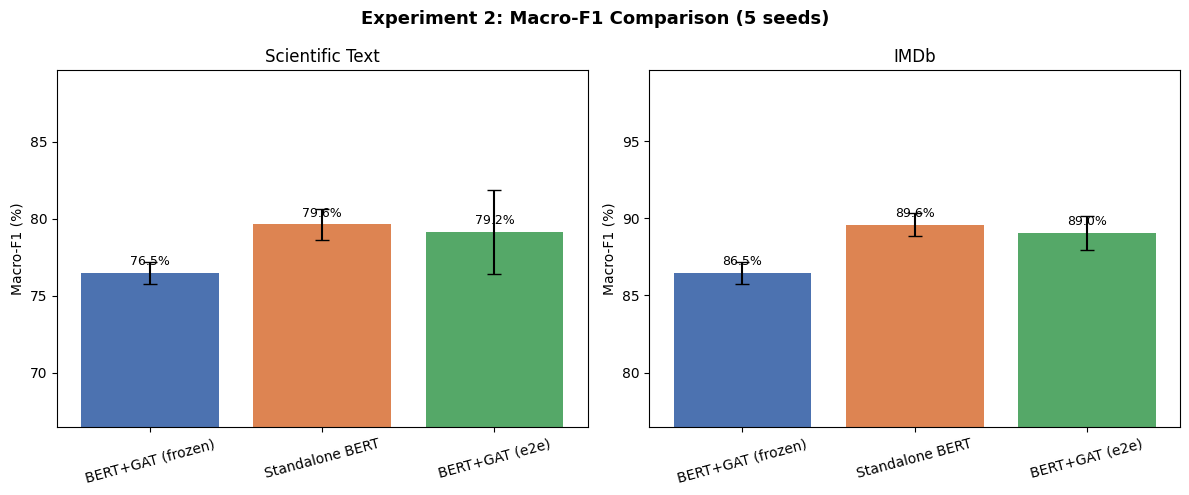

In [21]:
# ── Full comparison: all 3 conditions ────────────────────────────────────────
all_results = {
    'scientific': {
        'bert_gat_frozen': res2_sci_gat,
        'standalone_bert': res2_sci_bert,
        'bert_gat_e2e':    res2b_sci_e2e,
    },
    'imdb': {
        'bert_gat_frozen': res2_imdb_gat,
        'standalone_bert': res2_imdb_bert,
        'bert_gat_e2e':    res2b_imdb_e2e,
    },
}
save_results('results/exp2_all_results.json', all_results)

labels_map = {
    'bert_gat_frozen': 'BERT+GAT (frozen)',
    'standalone_bert': 'Standalone BERT',
    'bert_gat_e2e':    'BERT+GAT (e2e)',
}
colors = ['#4C72B0', '#DD8452', '#55A868']

print('\n{}'.format('=' * 62))
print('EXPERIMENT 2 – FULL COMPARISON  (Macro-F1, mean ± std, 5 seeds)')
print('=' * 62)
for ds_name, ds_key in [('Scientific Text', 'scientific'), ('IMDb', 'imdb')]:
    print('\n  {}:'.format(ds_name))
    for cond_key, cond_label in labels_map.items():
        r = all_results[ds_key][cond_key]
        print('    {:25s}: {:.2f} ± {:.2f}%'.format(cond_label, r['f1_mean'], r['f1_std']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (ds_name, ds_key) in zip(axes, [('Scientific Text', 'scientific'), ('IMDb', 'imdb')]):
    means = [all_results[ds_key][k]['f1_mean'] for k in labels_map]
    stds  = [all_results[ds_key][k]['f1_std']  for k in labels_map]
    bars  = ax.bar(list(labels_map.values()), means, yerr=stds, capsize=5, color=colors)
    ax.set_ylabel('Macro-F1 (%)')
    ax.set_title(ds_name)
    ax.set_ylim(max(0, min(means) - 10), min(100, max(means) + 10))
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                '{:.1f}%'.format(val), ha='center', va='bottom', fontsize=9)
plt.suptitle('Experiment 2: Macro-F1 Comparison (5 seeds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/exp2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Discussion

### Data integrity
The train/validation/test split (70/15/15) is stratified by label and uses a fixed random seed (42), so all three models see exactly the same test set. The BERT tokenizer comes pre-trained from HuggingFace and is not fitted on our data in any way. No data leakage was found.

### Why BERT+GAT does not clearly beat standalone BERT

First, the frozen BERT+GAT is noticeably worse than standalone BERT. Second, the end-to-end BERT+GAT comes very close to standalone BERT (e.g. 89.0% vs 89.6% F1 on IMDb) but still does not beat it. There are three reasons for this.

**BERT already understands syntax.** BERT is trained on a huge amount of text and its attention heads learn to pick up on grammatical structure, including the same word relationships that our dependency graph encodes. When we add a GAT on top, we are not giving the model new information — we are mostly repeating what BERT already knows internally.

**We throw away the CLS token.** Standalone BERT classifies a text using the special `[CLS]` token, which BERT is specifically pre-trained to use as a summary of the whole sentence. Our BERT+GAT model ignores this token and instead averages all word embeddings with `global_mean_pool`. This is a weaker way to summarise the document and likely explains a good part of the remaining gap.

**The graph sees less text.** Before building the graph, spaCy tokenisation is truncated at 256 tokens. Standalone BERT can read up to 512 sub-word tokens directly. For long texts like IMDb reviews, the graph-based models therefore work with less of the document.

The end-to-end variant largely closes the gap with standalone BERT, which confirms that freezing BERT was the main bottleneck, not the graph itself. However, the graph structure still does not provide a clear advantage. For document-level classification, explicitly encoding dependency structure does not improve over what BERT already captures through self-attention.
